# Predicción de Importe de Venta — 1000 Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [9]:
df = pd.read_csv("DatosLineales1000.csv", skiprows=1, names=["Unidades", "Importe"])
df = df[df["Unidades"] != "xi"].copy()
df["Unidades"] = pd.to_numeric(df["Unidades"], errors="coerce")
df["Importe"] = df["Importe"].str.replace("€", "").str.replace(",", "").str.strip()
df["Importe"] = pd.to_numeric(df["Importe"], errors="coerce")
df = df.dropna()
df

,Unidades,Importe
1,7271,1887050.62
2,861,312191.14
3,5391,1433899.12
4,5192,1368172.75
5,5735,1464853.85
...,...,...
996,8555,2177868.53
997,2444,708483.62
998,7784,2004240.43
999,985,306978.73


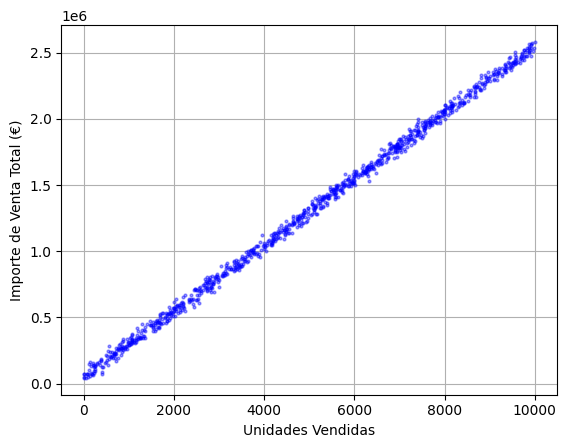

In [17]:
%matplotlib inline
plt.plot(df["Unidades"], df["Importe"], "b.", alpha=0.4, markersize=4)
plt.xlabel("Unidades Vendidas")
plt.ylabel("Importe de Venta Total (€)")
plt.grid(True)
plt.show()

# Construir un modelo

In [11]:
modelo = LinearRegression()
modelo.fit(df["Unidades"].values.reshape(-1, 1), df["Importe"].values)
print("Pendiente (m):", modelo.coef_[0])
print("Intercepto (b):", modelo.intercept_)

Pendiente (m): 249.5262896188765
Intercepto (b): 54450.64128203341


In [12]:
X_min_max = np.array([[df["Unidades"].min()], [df["Unidades"].max()]])
y_pred_line = modelo.predict(X_min_max)
print("Predicción en mínimo:", y_pred_line[0])
print("Predicción en máximo:", y_pred_line[1])

Predicción en mínimo: 55698.27273012779
Predicción en máximo: 2549464.0111811794


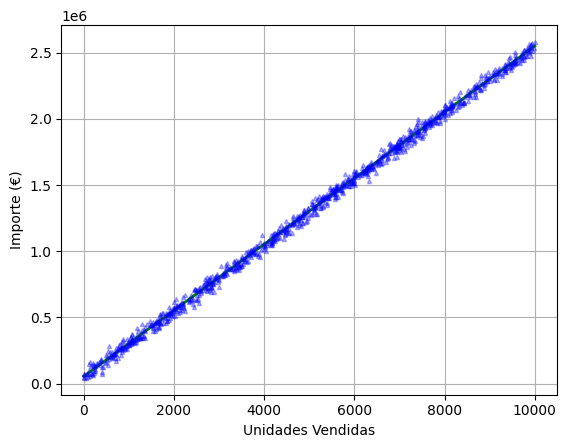

In [13]:
plt.plot(X_min_max, y_pred_line, "g-", linewidth=2)
plt.plot(df["Unidades"], df["Importe"], "b^", alpha=0.3, markersize=3)
plt.xlabel("Unidades Vendidas")
plt.ylabel("Importe (€)")
plt.grid(True)
plt.show()

## Predicción

In [14]:
X_new = np.array([[5000]])
importe_pred = modelo.predict(X_new)
print("Para 5000 unidades vendidas, el importe estimado es: €{:,.2f}".format(importe_pred[0]))

Para 5000 unidades vendidas, el importe estimado es: €1,302,082.09


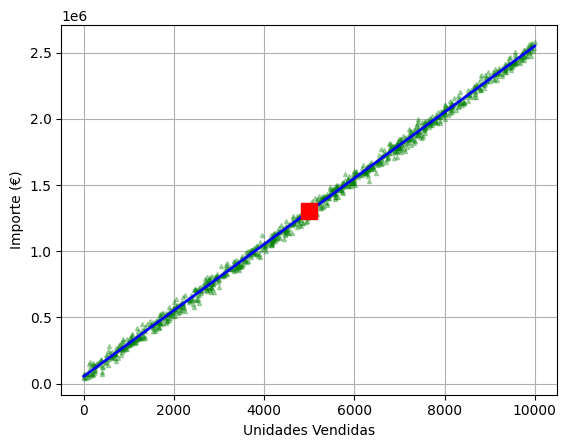

In [16]:
plt.plot(df["Unidades"], df["Importe"], "g^", alpha=0.3, markersize=3)
plt.plot(X_min_max, y_pred_line, "b-", linewidth=2)
plt.plot(X_new, importe_pred, "rs", markersize=12, label="€{:,.0f}".format(importe_pred[0]))
plt.xlabel("Unidades Vendidas")
plt.ylabel("Importe (€)")
plt.grid(True)
plt.show()